In [ ]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from itertools import cycle
import numpy as np
import random
import os

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"PyTorch Version: {torch.__version__}")

In [ ]:
DATA_DIR = 'Data'
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.0001

train_dir = os.path.join(DATA_DIR, 'train')
valid_dir = os.path.join(DATA_DIR, 'valid')
test_dir = os.path.join(DATA_DIR, 'test')

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# Mixed precision (fp16 forward pass) roughly doubles-to-10x throughput on
# both MPS and CUDA with negligible accuracy impact for fine-tuning.
use_amp = device.type in ("cuda", "mps")

print(f"Using device: {device}")
if device.type == "cpu":
    print("WARNING: training on CPU — this will be significantly slower.")
print(f"Mixed precision (AMP) enabled: {use_amp}")

In [ ]:
# CT scans are grayscale, so hue/saturation jitter adds nothing — use
# geometric augmentation plus mild brightness/contrast instead.
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

valid_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_data = datasets.ImageFolder(valid_dir, transform=valid_test_transforms)
test_data = datasets.ImageFolder(test_dir, transform=valid_test_transforms)

generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          generator=generator, num_workers=4, persistent_workers=True)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE,
                          num_workers=4, persistent_workers=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE,
                         num_workers=4, persistent_workers=True)

class_names = train_data.classes
print(f"Classes found: {class_names}")

In [7]:
from torchsummary import summary

model = models.resnet50(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(class_names))
)

model = model.to(device)

In [ ]:
# Weight the loss inversely to class frequency so minority carcinoma
# classes aren't under-predicted.
counts = np.bincount([label for _, label in train_data.samples])
class_weights = torch.tensor(len(train_data.samples) / (len(class_names) * counts),
                             dtype=torch.float).to(device)
print(f"Train class counts: {dict(zip(class_names, counts))}")
print(f"Loss weights: {class_weights.cpu().numpy().round(3)}")

params_to_update = [
    {'params': model.layer4.parameters(), 'lr': 0.00001},
    {'params': model.fc.parameters(), 'lr': LEARNING_RATE}
]

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(params_to_update)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                 factor=0.5, patience=3)

print("Optimizer configured with different learning rates for ResNet fine-tuning.")

In [ ]:
valid_loss_min = np.inf

for epoch in range(1, EPOCHS + 1):
    train_loss = 0.0
    valid_loss = 0.0

    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            output = model(images)
            loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)

    model.eval()
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                output = model(images)
                loss = criterion(output, labels)
            valid_loss += loss.item() * images.size(0)

    train_loss = train_loss / len(train_loader.dataset)
    valid_loss = valid_loss / len(valid_loader.dataset)

    # Halve the learning rate when validation loss plateaus
    scheduler.step(valid_loss)
    current_lr = optimizer.param_groups[1]['lr']

    print(f'Epoch: {epoch} \tTraining Loss: {train_loss:.6f} \tValidation Loss: {valid_loss:.6f} \tHead LR: {current_lr:.6f}')

    if valid_loss <= valid_loss_min:
        print('Validation loss decreased. Saving model...')
        torch.save(model.state_dict(), 'best_resnet_model.pt')
        valid_loss_min = valid_loss

In [ ]:
model.load_state_dict(torch.load('best_resnet_model.pt', weights_only=True))
model.to(device)

model.eval()
y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            outputs = model(images)
        probabilities = F.softmax(outputs.float(), dim=1)
        predicted = outputs.argmax(1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_prob.extend(probabilities.cpu().numpy())

y_prob = np.array(y_prob)

print(f"\nTest Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

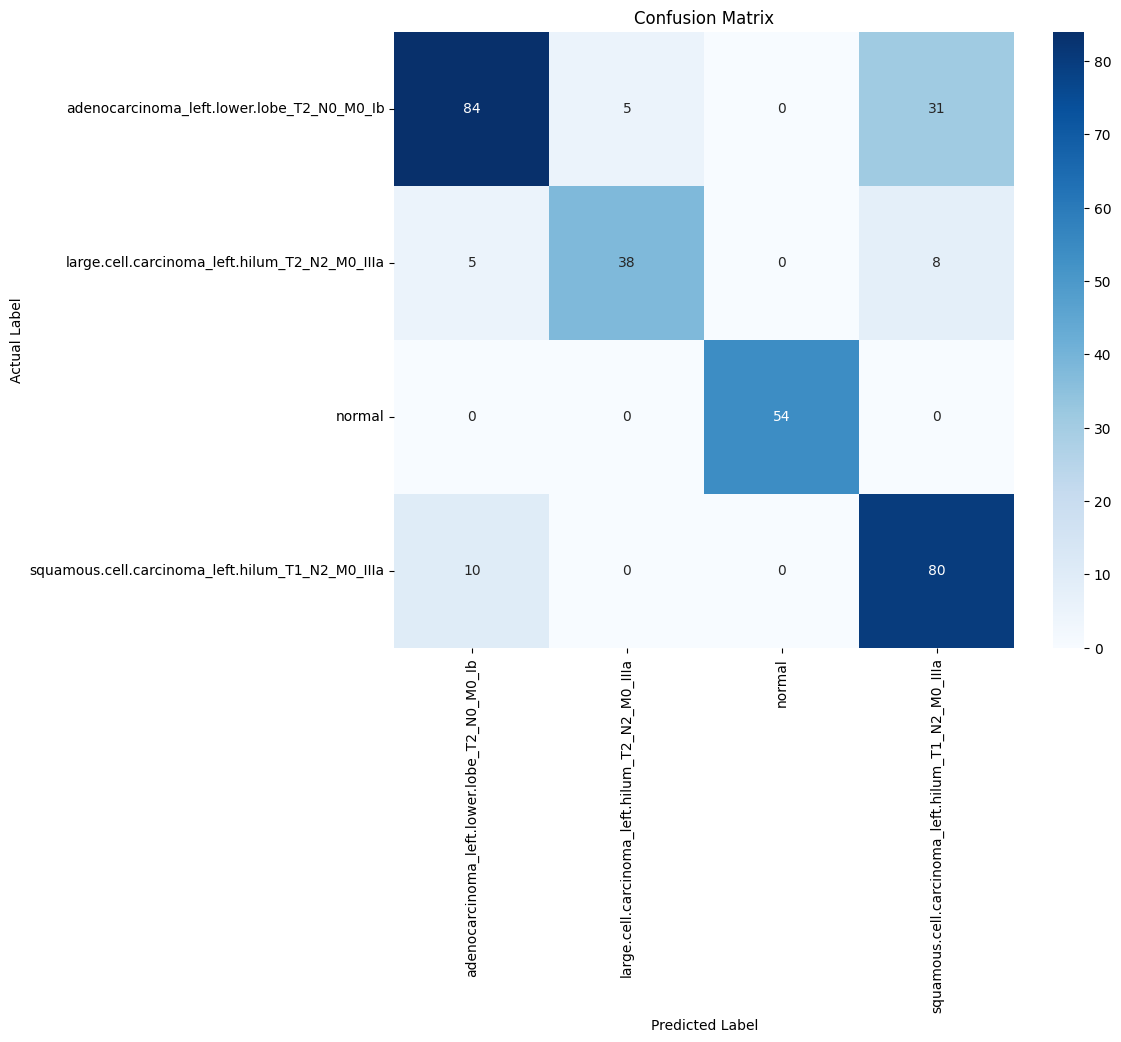

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# --- 1. Calculate Specificity from the Confusion Matrix ---
print("--- Specificity ---")
for i, class_name in enumerate(class_names):
    tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
    fp = np.sum(cm[:, i]) - cm[i, i]
    specificity = tn / (tn + fp)
    print(f'Specificity for {class_name}: {specificity:.4f}')

# --- 2. Calculate Cohen's Kappa and MCC ---
kappa = cohen_kappa_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
print("\n--- Overall Performance Metrics ---")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

# --- 3. AUC-ROC Score and Curve (probabilities already collected during evaluation) ---
# Binarize the true labels for multi-class ROC calculation
y_true_binarized = label_binarize(y_true, classes=range(len(class_names)))

# Calculate the AUC score
auc_score = roc_auc_score(y_true_binarized, y_prob, multi_class='ovr', average='weighted')
print(f"\nWeighted Average AUC Score (One-vs-Rest): {auc_score:.4f}\n")

# --- Plotting the ROC Curve for each class ---
fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green'])

for i, color in zip(range(len(class_names)), colors):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_prob[:, i])
    roc_auc[i] = roc_auc_score(y_true_binarized[:, i], y_prob[:, i])
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

## Architecture Comparison: ResNet50 vs EfficientNet-B0

Trains a second backbone with the identical transfer-learning protocol — frozen backbone, last-stage fine-tuning, class-weighted loss, LR scheduling, AMP — so the two architectures are compared fairly on the same data and metrics.

In [ ]:
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                outputs = model(images)
            probabilities = F.softmax(outputs.float(), dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(outputs.argmax(1).cpu().numpy())
            y_prob.extend(probabilities.cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_prob)


def compute_metrics(y_true, y_pred, y_prob):
    y_true_binarized = label_binarize(y_true, classes=range(len(class_names)))
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'auc': roc_auc_score(y_true_binarized, y_prob, multi_class='ovr', average='weighted'),
        'kappa': cohen_kappa_score(y_true, y_pred),
        'mcc': matthews_corrcoef(y_true, y_pred),
    }


def train_model(model, optimizer, scheduler, checkpoint_path, epochs):
    valid_loss_min = np.inf
    for epoch in range(1, epochs + 1):
        train_loss = 0.0
        valid_loss = 0.0

        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                output = model(images)
                loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)

        model.eval()
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                    output = model(images)
                    loss = criterion(output, labels)
                valid_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)
        valid_loss /= len(valid_loader.dataset)
        scheduler.step(valid_loss)

        print(f'Epoch: {epoch} \tTraining Loss: {train_loss:.6f} \tValidation Loss: {valid_loss:.6f}')

        if valid_loss <= valid_loss_min:
            print('Validation loss decreased. Saving model...')
            torch.save(model.state_dict(), checkpoint_path)
            valid_loss_min = valid_loss

In [ ]:
# Reload the already-trained ResNet50 from its checkpoint so both
# architectures are evaluated identically in this comparison section.
resnet_model = models.resnet50(weights=None)
resnet_model.fc = nn.Sequential(
    nn.Linear(resnet_model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(class_names))
)
resnet_model.load_state_dict(torch.load('best_resnet_model.pt', weights_only=True))
resnet_model = resnet_model.to(device)

results = {}
r_true, r_pred, r_prob = evaluate_model(resnet_model, test_loader)
results['ResNet50'] = compute_metrics(r_true, r_pred, r_prob)
print(f"ResNet50: {results['ResNet50']}")

In [ ]:
effnet_model = models.efficientnet_b0(weights='IMAGENET1K_V1')

for param in effnet_model.parameters():
    param.requires_grad = False

# Unfreeze the last MBConv stage + final conv — the closest analog to
# fine-tuning ResNet's layer4 (the deepest, most task-specific features).
for param in effnet_model.features[7].parameters():
    param.requires_grad = True
for param in effnet_model.features[8].parameters():
    param.requires_grad = True

num_ftrs = effnet_model.classifier[1].in_features
effnet_model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(class_names))
)

effnet_model = effnet_model.to(device)

In [ ]:
# Same discriminative-LR scheme and class-weighted criterion as ResNet50,
# so any accuracy gap reflects the architecture, not the training recipe.
effnet_params = [
    {'params': effnet_model.features[7].parameters(), 'lr': 0.00001},
    {'params': effnet_model.features[8].parameters(), 'lr': 0.00001},
    {'params': effnet_model.classifier.parameters(), 'lr': LEARNING_RATE}
]
effnet_optimizer = optim.Adam(effnet_params)
effnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(effnet_optimizer, mode='min',
                                                        factor=0.5, patience=3)

train_model(effnet_model, effnet_optimizer, effnet_scheduler, 'best_effnet_model.pt', EPOCHS)

In [ ]:
effnet_model.load_state_dict(torch.load('best_effnet_model.pt', weights_only=True))
e_true, e_pred, e_prob = evaluate_model(effnet_model, test_loader)
results['EfficientNet-B0'] = compute_metrics(e_true, e_pred, e_prob)

print(f"{'Metric':<14}{'ResNet50':>12}{'EfficientNet-B0':>18}")
for metric in ['accuracy', 'auc', 'kappa', 'mcc']:
    r, e = results['ResNet50'][metric], results['EfficientNet-B0'][metric]
    print(f"{metric:<14}{r:>12.4f}{e:>18.4f}")

In [ ]:
metrics = ['accuracy', 'auc', 'kappa', 'mcc']
metric_labels = ['Accuracy', 'AUC-ROC', "Cohen's Kappa", 'MCC']
model_names = ['ResNet50', 'EfficientNet-B0']
colors = ['#2a78d6', '#1baf7a']  # fixed categorical order — never swap per-chart

x = np.arange(len(metrics))
width = 0.32

fig, ax = plt.subplots(figsize=(9, 5.5))
for i, (name, color) in enumerate(zip(model_names, colors)):
    values = [results[name][m] for m in metrics]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, values, width, label=name, color=color,
                  edgecolor='white', linewidth=0.5)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9, color='#52514e')

ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_title('ResNet50 vs EfficientNet-B0 — Test Set Metrics')
ax.legend(frameon=False)
for spine in ('top', 'right', 'left'):
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='both', colors='#898781')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()